In [14]:
import pandas as pd

# Load the dataset from the URL
df = pd.read_csv('/content/TvMarketing.csv')

# Display the first 5 rows of the DataFrame
print('DataFrame Head:')
print(df.head())

# Display a concise summary of the DataFrame
print('\nDataFrame Info:')
df.info()

# Generate descriptive statistics of the DataFrame
print('\nDataFrame Descriptive Statistics:')
print(df.describe())

DataFrame Head:
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

DataFrame Descriptive Statistics:
               TV       Sales
count  200.000000  200.000000
mean   147.042500   14.022500
std     85.854236    5.217457
min      0.700000    1.600000
25%     74.375000   10.375000
50%    149.750000   12.900000
75%    218.825000   17.400000
max    296.400000   27.000000


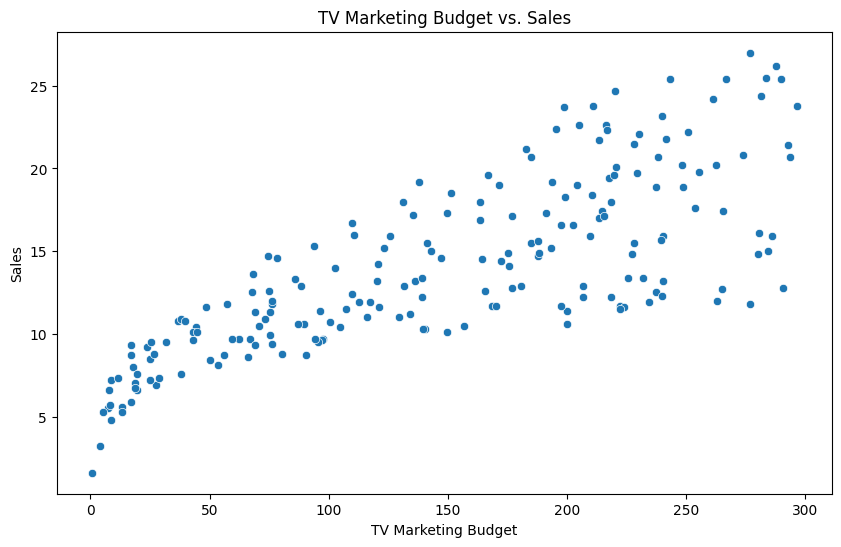

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of 'TV' vs 'Sales'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Marketing Budget vs. Sales')
plt.xlabel('TV Marketing Budget')
plt.ylabel('Sales')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['TV']]
y = df['Sales']

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (160, 1)
Shape of X_test: (40, 1)
Shape of y_train: (160,)
Shape of y_test: (40,)


In [16]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model instance
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Display the optimal model parameters
print('Coefficient (slope):', model.coef_[0])
print('Intercept:', model.intercept_)

Coefficient (slope): 0.046529733705443346
Intercept: 7.119638430592953


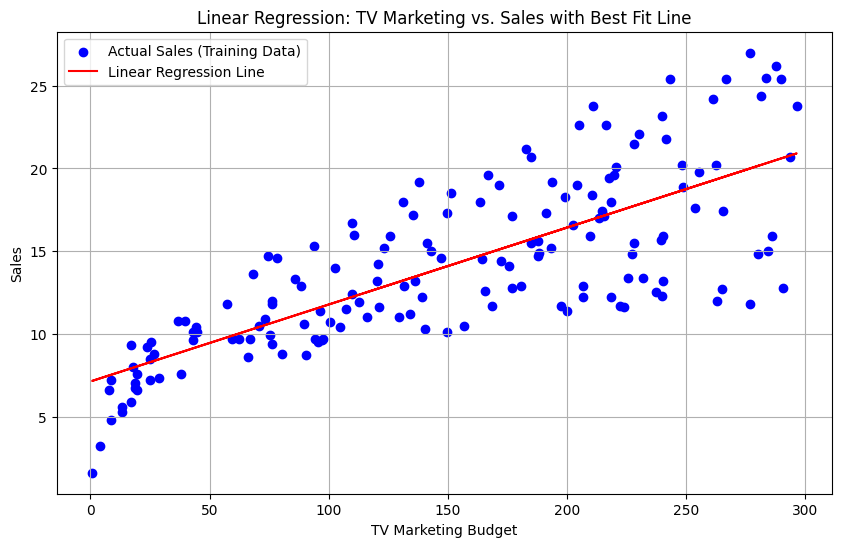

In [17]:
import matplotlib.pyplot as plt

# Create a scatter plot of the training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Actual Sales (Training Data)')

# Predict sales values using the trained model on X_train
y_train_pred = model.predict(X_train)

# Plot the linear regression line
plt.plot(X_train, y_train_pred, color='red', label='Linear Regression Line')

# Add labels and title
plt.xlabel('TV Marketing Budget')
plt.ylabel('Sales')
plt.title('Linear Regression: TV Marketing vs. Sales with Best Fit Line')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import pandas as pd

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create a DataFrame to compare actual vs. predicted sales
comparison_df = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred})

# Display the head of the comparison DataFrame
print('Actual vs. Predicted Sales (Test Data):')
print(comparison_df.head())

Actual vs. Predicted Sales (Test Data):
     Actual Sales  Predicted Sales
95           16.9        14.717944
15           22.4        16.211548
30           21.4        20.748197
158           7.3         7.664036
128          24.7        17.370139


In [19]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Root Mean Squared Error (RMSE): 3.19
R-squared (R2): 0.68
